# Dusty Red Galaxies in COSMOS-Web
AP 2026

In [13]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
# imports
import numpy as np
import matplotlib.pyplot as plt
from utilities.cosmosWebHandler import CosmosWebHandler


In [ ]:
# constants
CATALOG_PATH = "/Volumes/Apple SDXC Reader Media/dusty-red/data/COSMOSWeb_mastercatalog_v1.1.fits"


In [5]:
# load the handler
cosmosWebHandler = CosmosWebHandler(CATALOG_PATH)
cosmosWebHandler.load_catalog()

Filename: /Volumes/Apple SDXC Reader Media/dusty-red/COSMOSWeb_mastercatalog_v1.1.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  PHOTOMETRY HOTCOLD AND SE++    1 BinTableHDU    603   784016R x 287C   [K, K, 3A, K, D, D, D, D, D, D, D, D, D, 4A, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, 5D, 5D, 5D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, L, L, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, K, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D, D

### sanity checks

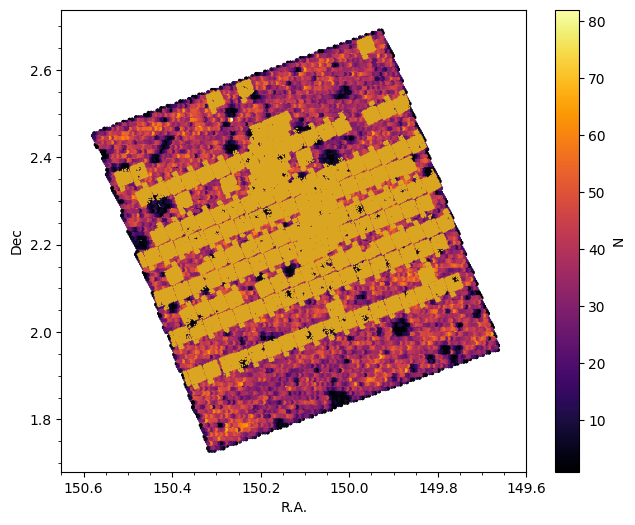

In [ ]:
# test, plot miri
fig, ax = plt.subplots(1,1, figsize=(7.5, 6))

ax.hexbin(cosmosWebHandler.get_cat_photom()['ra'], cosmosWebHandler.get_cat_photom()['dec'], gridsize=160, cmap='gray', mincnt=1)

hb = ax.hexbin(cosmosWebHandler.get_cat_photom('condition_clean')['ra'], cosmosWebHandler.get_cat_photom('condition_clean')['dec'], gridsize=160, cmap='inferno', mincnt=1)

ax.plot(cosmosWebHandler.get_cat_photom('condition_clean_miri')['ra'], cosmosWebHandler.get_cat_photom('condition_clean_miri')['dec'], 'o', ms=1.0, markeredgecolor='None', alpha=1, color='goldenrod')

cb = fig.colorbar(hb, ax=ax)
cb.set_label('N')
ax.set_xlabel('R.A.')
ax.set_ylabel('Dec')
ax.set_xlim(150.65, 149.6)
ax.minorticks_on()

## make detection cuts

Filter cut: 2347 out of 193362 objects remain. Fraction: 1.21%


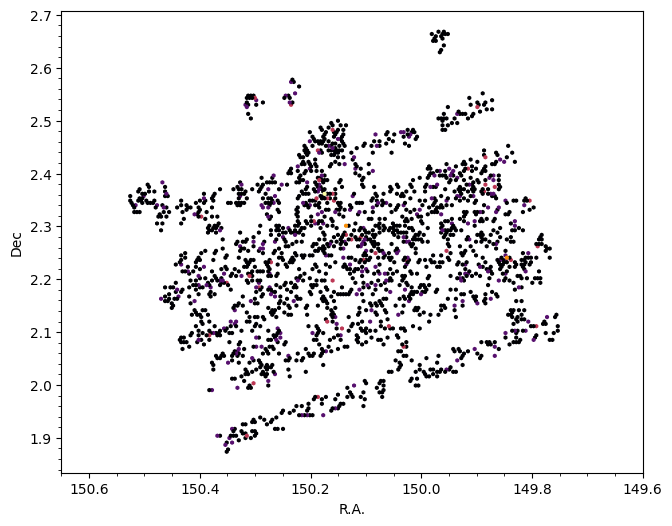

In [ ]:
# make selection:
# S/N<3 for non-detection flux_model_f115w/flux_err-cal_model_f115w < 3 

condition_non_detection = cosmosWebHandler.get_filter_cut(filtername='condition_non_detection', filter_func=lambda photom, lephare, cigale, bd: (photom['flux_model_f277w']/photom['flux_err-cal_model_f277w'] >= 3) & (photom['flux_model_f115w']/photom['flux_err-cal_model_f115w'] >= 3) & (photom['flux_model_f150w']/photom['flux_err-cal_model_f150w'] >= 3) & (photom['flux_model_f444w']/photom['flux_err-cal_model_f444w'] < 5) & (photom['flux_model_f770w']/photom['flux_err-cal_model_f770w'] < 5))

#plot the non-detections
figNonDetection, axNonDetection = plt.subplots(1,1, figsize=(7.5, 6))

axNonDetection.hexbin(cosmosWebHandler.get_cat_photom('condition_non_detection')['ra'], cosmosWebHandler.get_cat_photom('condition_non_detection')['dec'], gridsize=160, cmap='inferno', mincnt=1)

axNonDetection.set_xlabel('R.A.')
axNonDetection.set_ylabel('Dec')
axNonDetection.set_xlim(150.65, 149.6)
axNonDetection.minorticks_on()



Filter cut: 18 out of 193362 objects remain. Fraction: 0.01%


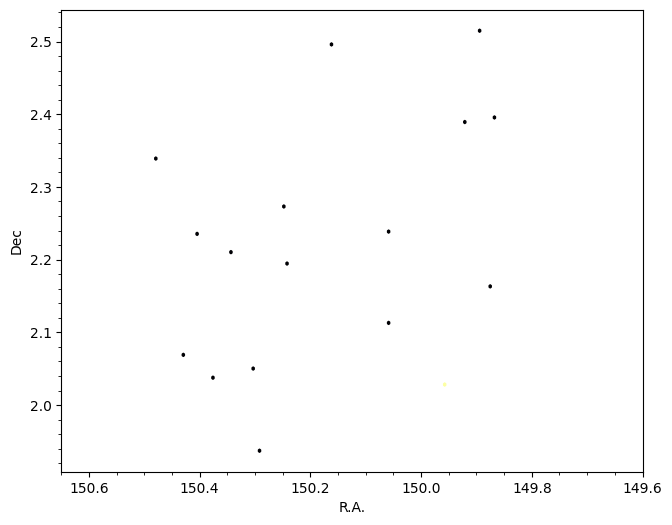

In [28]:

condition_detection = cosmosWebHandler.get_filter_cut(filtername='condition_detection', filter_func=lambda photom, lephare, cigale, bd: (photom['flux_model_f277w']/photom['flux_err-cal_model_f277w'] < 3) & (photom['flux_model_f115w']/photom['flux_err-cal_model_f115w'] < 3) & (photom['flux_model_f150w']/photom['flux_err-cal_model_f150w'] < 3) & (photom['flux_model_f444w']/photom['flux_err-cal_model_f444w'] >= 5) & (photom['flux_model_f770w']/photom['flux_err-cal_model_f770w'] >= 5))
                                                                                                                                                                                                                

figDetection, axDetection = plt.subplots(1,1, figsize=(7.5, 6))
axDetection.hexbin(cosmosWebHandler.get_cat_photom('condition_detection')['ra'], cosmosWebHandler.get_cat_photom('condition_detection')['dec'], gridsize=160, cmap='inferno', mincnt=1)

axDetection.set_xlabel('R.A.')
axDetection.set_ylabel('Dec')
axDetection.set_xlim(150.65, 149.6)
axDetection.minorticks_on()


### see detection images from tile

In [30]:
# get the tiles the 18 detected objects are in, and plot them as an interactive plot so that we can cycle through them
cat_photom_condition_detection = cosmosWebHandler.get_cat_photom('condition_detection')
cat_photom_condition_detection['tile']
print(np.unique(cat_photom_condition_detection['tile']))

['A1' 'A10' 'A3' 'A5' 'A7' 'B1' 'B10' 'B3' 'B5' 'B6' 'B7' 'B9']


In [ ]:
# visualize the 18 detected objects: detection map + f115w/f150w/f444w/f770w
# cutouts side by side, cycled with ipywidgets.
#
# Detection tiles (detection_chi2pos_SWLW_<TILE>.fits) are single-channel chi^2
# maps. The per-band panels use COSMOS-Web DR1 mosaics (cosmos2025.iap.fr),
# naming:  mosaic_nircam_f115w_COSMOS-Web_30mas_A1_v1.0_sci.fits[.gz]
# Any band whose file is not found renders as a "missing" placeholder.

import os
import ipywidgets as widgets
from IPython.display import display
from astropy.coordinates import SkyCoord
from astropy.wcs import WCS
from astropy.nddata import Cutout2D
from astropy.io import fits
from astropy.visualization import ImageNormalize, ZScaleInterval, AsinhStretch
import astropy.units as u

DATA_DIR    = '/Volumes/Apple SDXC Reader Media/dusty-red/data'   # folder with the tiles
CUTOUT_SIZE = 3.0 * u.arcsec                                      # box size on a side
PIXSCALE    = '30mas'                                             # '30mas' or '60mas'
EXT         = '.fits'                                             # '.fits.gz' if kept gzipped

# Ordered panels: (label, filename template). {tile} is filled per object;
# templates without {tile} are treated as a single mosaic for all objects.
PANELS = [
    ('detection', 'detection_chi2pos_SWLW_{tile}.fits'),
    ('f115w', f'mosaic_nircam_f115w_COSMOS-Web_{PIXSCALE}_{{tile}}_v1.0_sci{EXT}'),
    ('f150w', f'mosaic_nircam_f150w_COSMOS-Web_{PIXSCALE}_{{tile}}_v1.0_sci{EXT}'),
    ('f444w', f'mosaic_nircam_f444w_COSMOS-Web_{PIXSCALE}_{{tile}}_v1.0_sci{EXT}'),
    ('f770w', f'mosaic_miri_f770w_COSMOS-Web_{PIXSCALE}_{{tile}}_v1.0_sci{EXT}'),  # MIRI: verify exact name
]

_cat = cosmosWebHandler.get_cat_photom('condition_detection')
_ra, _dec = np.asarray(_cat['ra']), np.asarray(_cat['dec'])
_tile = np.asarray(_cat['tile']).astype(str)
_ids = np.asarray(_cat['id']) if 'id' in _cat.colnames else np.arange(len(_cat))
_n = len(_cat)


def _img_hdu(hdul):
    """Return (data, header) for the first HDU holding a 2-D image."""
    for h in hdul:
        if h.data is not None and h.data.ndim == 2:
            return h.data, h.header
    raise ValueError("No 2-D image HDU found.")


_cache = {}   # (label, tile) -> (data memmap, wcs) or None if file absent

def _load(label, template, tile):
    key = (label, tile)
    if key not in _cache:
        path = os.path.join(DATA_DIR, template.format(tile=tile))
        if os.path.exists(path):
            data, hdr = _img_hdu(fits.open(path, memmap=True))
            _cache[key] = (data, WCS(hdr))
        else:
            _cache[key] = None
    return _cache[key]


def _draw_panel(ax, label, template, ra, dec, tile):
    loaded = _load(label, template, tile)
    if loaded is None:
        ax.text(0.5, 0.5, f"{label}\n(missing)", ha='center', va='center', fontsize=9)
        ax.set_axis_off()
        return
    data, wcs = loaded
    pos = SkyCoord(ra, dec, unit='deg')
    scale = np.abs(wcs.proj_plane_pixel_scales()[0].to(u.arcsec))
    npix = int(round((CUTOUT_SIZE / scale).decompose().value))
    stamp = Cutout2D(data, pos, npix, wcs=wcs, mode='partial', fill_value=0.0).data
    norm = ImageNormalize(stamp, interval=ZScaleInterval(), stretch=AsinhStretch())
    ax.imshow(stamp, origin='lower', cmap='gray', norm=norm)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(label, fontsize=10)


_slider = widgets.IntSlider(min=0, max=_n - 1, step=1, value=0, description='object')
_prev = widgets.Button(description='◀ Prev')
_next = widgets.Button(description='Next ▶')
_out = widgets.Output()


def _show(i):
    with _out:
        _out.clear_output(wait=True)
        fig, axes = plt.subplots(1, len(PANELS), figsize=(3.2 * len(PANELS), 3.4))
        for ax, (label, template) in zip(np.atleast_1d(axes), PANELS):
            _draw_panel(ax, label, template, _ra[i], _dec[i], _tile[i])
        fig.suptitle(f"[{i + 1}/{_n}]  id={_ids[i]}  tile {_tile[i]}  "
                     f"RA={_ra[i]:.5f}  Dec={_dec[i]:.5f}", fontsize=11)
        fig.tight_layout()
        plt.show()


_slider.observe(lambda change: _show(change['new']), names='value')
_prev.on_click(lambda _: setattr(_slider, 'value', max(0, _slider.value - 1)))
_next.on_click(lambda _: setattr(_slider, 'value', min(_n - 1, _slider.value + 1)))

display(widgets.HBox([_prev, _slider, _next]), _out)
_show(_slider.value)   # render the first object immediately


### see detection from inspection plots

In [ ]:
# cycle through the 18 detected objects, showing the COSMOS-Web DR1 per-source
# inspection plot (SED) for each via "https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"
import requests
import fitz  # PyMuPDF
from IPython.display import Image, display
import ipywidgets as widgets

pdf_url_sourceid = lambda sid: f"https://cosmos2025.iap.fr/fitsmap/data/inspec_plots/cosmos_web_sed_{sid}.pdf"

_cat_sed = cosmosWebHandler.get_cat_photom('condition_detection')
_sids = np.asarray(_cat_sed['id'])
_tiles_sed = np.asarray(_cat_sed['tile']).astype(str)
_n_sed = len(_sids)

_png_cache = {}   # sid -> list of PNG byte-strings (one per page)

def _render_pdf(sid, dpi=130):
    if sid not in _png_cache:
        r = requests.get(pdf_url_sourceid(sid), timeout=30)
        r.raise_for_status()
        doc = fitz.open(stream=r.content, filetype='pdf')
        _png_cache[sid] = [doc.load_page(p).get_pixmap(dpi=dpi).tobytes('png')
                           for p in range(doc.page_count)]
        doc.close()
    return _png_cache[sid]


_slider_sed = widgets.IntSlider(min=0, max=_n_sed - 1, step=1, value=0, description='object')
_prev_sed = widgets.Button(description='◀ Prev')
_next_sed = widgets.Button(description='Next ▶')
_out_sed = widgets.Output()


def _show_sed(i):
    with _out_sed:
        _out_sed.clear_output(wait=True)
        sid = int(_sids[i])
        print(f"[{i + 1}/{_n_sed}]  id={sid}  tile {_tiles_sed[i]}")
        if fitz is None:
            print("Install PyMuPDF to render the inspection plots:  pip install pymupdf")
            print("Direct link:", pdf_url_sourceid(sid))
            return
        try:
            for png in _render_pdf(sid):
                display(Image(data=png))
        except Exception as e:
            print(f"Could not load plot for id={sid}: {e}")
            print("Direct link:", pdf_url_sourceid(sid))


_slider_sed.observe(lambda change: _show_sed(change['new']), names='value')
_prev_sed.on_click(lambda _: setattr(_slider_sed, 'value', max(0, _slider_sed.value - 1)))
_next_sed.on_click(lambda _: setattr(_slider_sed, 'value', min(_n_sed - 1, _slider_sed.value + 1)))

display(widgets.HBox([_prev_sed, _slider_sed, _next_sed]), _out_sed)
_show_sed(_slider_sed.value)   # render the first object immediately


Output()

sketchy id's:
- id 9404 object 1/18 ; somewhat still visible in F277W but also not very well constrained so maybe okay
- id 89430 oject 2/18 ; seems more of artifact with star
- id 171453 object 3/18 ; somewhat still visible in F277W but also not very well constrained so maybe okay
- id 177683 object 4/18 ; potentially good portion still visible in F227W and also not appearing in F770W - also pretty well constrained
- id 253195 object 6/18 ; again seems more of artifiact with star and also no MIRI.
- id 253424 object 7/18 ; again seems more of artifiact with star and also no MIRI.
- id 384271 object 8/18 ; great but no MIRI
- id 495323 object 10/18 ; great but no MIRI
- id 569254 object 11/18 ; great but on edge of MIRI
- id 620573 objext 14/18 ; well-constrained, not really red, low redshift
- id 718984 object 16/18 ; well observed in f277w, decently well constrained
- id 781174 object 18/18 ; good but hard to observe in f770w